In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report


df = pd.read_csv('dataset/bank-full.csv')



In [2]:
df.replace("unknown", np.nan, inplace=True)

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df['y'] = df['y'].map({'yes': 1, 'no': 0})

categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
     df[col] = le.fit_transform(df[col])
    

X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

E:\temp\ipykernel_16516\1602024045.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns
E:\temp\ipykernel_16516\1602024045.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-d

In [3]:
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

model_xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    gamma=1,
    random_state=42,
    eval_metric='logloss'
)
model_xgb.fit(X_train_scaled, y_train)

pred_xgb = model_xgb.predict(X_test_scaled)

acc_xgb = accuracy_score(y_test, pred_xgb)

print("XGBoost Accuracy:", acc_xgb)

acc_xgb = accuracy_score(y_test, pred_xgb)
recall_xgb = recall_score(y_test, pred_xgb, average='weighted')
f1_xgb = f1_score(y_test, pred_xgb, average='weighted')
cm_xgb = confusion_matrix(y_test, pred_xgb)

# Output
print("===== XGBoost Evaluation =====")
print("Accuracy:", acc_xgb)
print("Recall:", recall_xgb)
print("F1 Score:", f1_xgb)

print("\nClassification Report:\n", classification_report(y_test, pred_xgb))

print("\nConfusion Matrix:\n", cm_xgb)

XGBoost Accuracy: 0.8876479044564857
===== XGBoost Evaluation =====
Accuracy: 0.8876479044564857
Recall: 0.8876479044564857
F1 Score: 0.8964030538748611

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.93      7952
           1       0.52      0.77      0.62      1091

    accuracy                           0.89      9043
   macro avg       0.74      0.84      0.78      9043
weighted avg       0.91      0.89      0.90      9043


Confusion Matrix:
 [[7190  762]
 [ 254  837]]


In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

model_xgb_pca = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    gamma=1,
    random_state=42,
    eval_metric='logloss'
    
)

model_xgb_pca.fit(X_train_pca, y_train)

pred_xgb_pca = model_xgb_pca.predict(X_test_pca)

acc_xgb_pca = accuracy_score(y_test, pred_xgb_pca)


print("PCA + XGBoost:", acc_xgb_pca)

acc_xgb_pca = accuracy_score(y_test, pred_xgb_pca)
recall_xgb_pca = recall_score(y_test, pred_xgb_pca, average='weighted')
f1_xgb_pca = f1_score(y_test, pred_xgb_pca, average='weighted')
cm_xgb_pca = confusion_matrix(y_test, pred_xgb_pca)

print("===== PCA + XGBoost Evaluation =====")
print("Accuracy:", acc_xgb_pca)
print("Recall:", recall_xgb_pca)
print("F1 Score:", f1_xgb_pca)

print("\nClassification Report:\n", classification_report(y_test, pred_xgb_pca))

print("\nConfusion Matrix:\n", cm_xgb_pca)

PCA + XGBoost: 0.8910759703638174
===== PCA + XGBoost Evaluation =====
Accuracy: 0.8910759703638174
Recall: 0.8910759703638174
F1 Score: 0.8944778490691304

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94      7952
           1       0.54      0.63      0.58      1091

    accuracy                           0.89      9043
   macro avg       0.74      0.78      0.76      9043
weighted avg       0.90      0.89      0.89      9043


Confusion Matrix:
 [[7373  579]
 [ 406  685]]


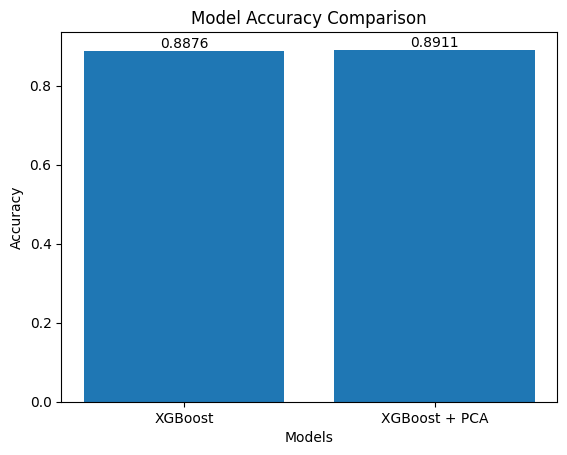

In [5]:
labels = ['XGBoost', 'XGBoost + PCA']
values = [acc_xgb, acc_xgb_pca]

plt.bar(labels, values)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

# إضافة القيم فوق الأعمدة
for i, v in enumerate(values):
    plt.text(i, v, str(round(v, 4)), ha='center', va='bottom')

plt.show()

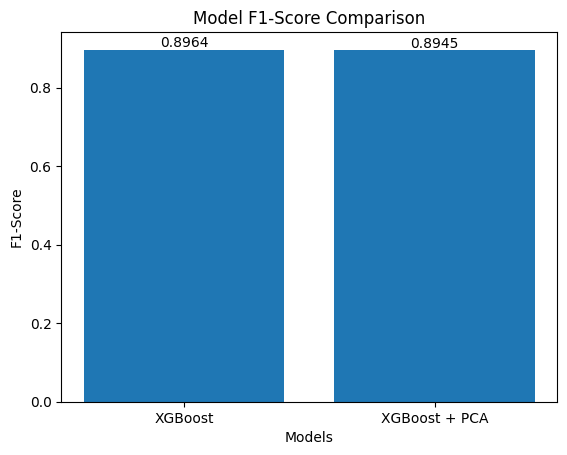

In [6]:
labels = ['XGBoost', 'XGBoost + PCA']
values = [f1_xgb, f1_xgb_pca]

plt.bar(labels, values)
plt.title("Model F1-Score Comparison")
plt.ylabel("F1-Score")
plt.xlabel("Models")

# إضافة القيم فوق الأعمدة
for i, v in enumerate(values):
    plt.text(i, v, str(round(v, 4)), ha='center', va='bottom')

plt.show()

In [7]:
##عمل Gridsearch 
grid = {'n_estimators':[50 ,150 ,200] , 
        'max_depth':[5 ,10 ,15]}
grid =GridSearchCV (
estimator =XGBClassifier() ,param_grid =grid ,cv=5 ,scoring='accuracy')
grid.fit(X_train ,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'n_estimators': [50, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displ

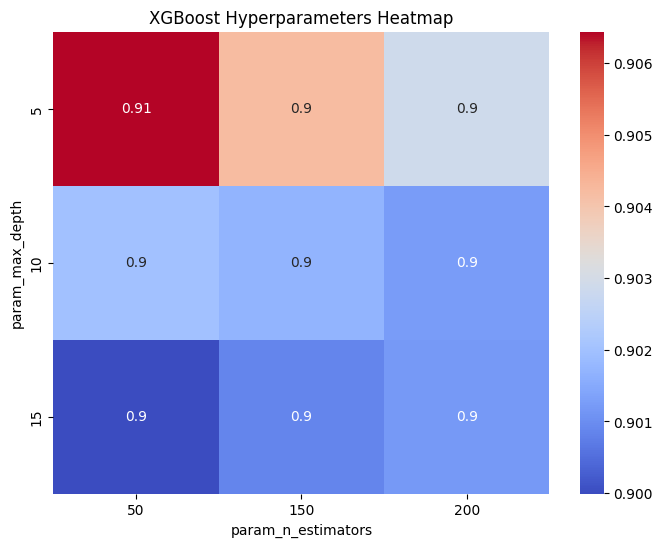

In [8]:
results =pd.DataFrame(grid.cv_results_)
pivot = results.pivot_table (values ='mean_test_score' ,index ='param_max_depth' , columns ='param_n_estimators')
plt.figure(figsize=(8,6))
sns.heatmap(pivot , annot=True , cmap='coolwarm')
plt.title('XGBoost Hyperparameters Heatmap')
plt.show()